# Tweet Preprocessing and Sentiment Labelling

This notebook processes tweets from the tweets folder, cleans them, and applies FinRoBERTa sentiment analysis.

**Process:**
1. Load tweet CSV files from tweets directory
2. Clean and preprocess tweet text (handles mentions, hashtags, URLs, emojis)
3. Apply FinRoBERTa sentiment analysis
4. Save labelled tweets with sentiment scores

## 1. Import Required Libraries

Import libraries for data processing, sentiment analysis, and file handling.

In [1]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from lingua import LanguageDetectorBuilder, Language
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import exchange_calendars

# Define the lingua English detector
lingua_detector = LanguageDetectorBuilder.from_all_languages().with_minimum_relative_distance(0.25).build()
print("Language Classifier loaded.")

# NYSE exchange calendar - sessions built lazily from data range in map_to_next_session()
nyse_cal = exchange_calendars.get_calendar("XNYS")


def map_to_next_session(bucket_dates_str):
    """Map each bucket date to the first NYSE session >= that date.

    Builds the session array from data min/max + 30-day buffer,
    so it never silently clips if data falls outside a hard-coded range.
    """
    bd = np.array(bucket_dates_str, dtype="datetime64[D]")
    d_min = str(bd.min() - np.timedelta64(30, "D"))
    d_max = str(bd.max() + np.timedelta64(30, "D"))
    sessions = nyse_cal.sessions_in_range(d_min, d_max)
    sess_np = sessions.values.astype("datetime64[D]")
    idx = np.searchsorted(sess_np, bd, side="left")
    idx = np.clip(idx, 0, len(sess_np) - 1)
    return sess_np[idx].astype(str)

Language Classifier loaded.


## 2. Directories and Settings

Set input directory (raw tweets) and output directory (processed tweets with sentiment).

**Directory Structure:**
- Input: `Raw_Data/Tweets/` folder containing `tweets_TICKER.csv` files
- Output: `Processed_Data/tweets_labelled/` folder for processed results

In [2]:
# Directories definitions
BASE_DIR = Path.cwd().resolve()
if (BASE_DIR / "Raw_Data" / "Tweets").exists():
    pass
elif (BASE_DIR.parent / "Raw_Data" / "Tweets").exists():
    BASE_DIR = BASE_DIR.parent

INPUT_DIR = str(BASE_DIR / "Raw_Data" / "Tweets")
OUTPUT_DIR = BASE_DIR / "Processed_Data" / "tweets_sentiment_daily"

print(f"BASE_DIR: {BASE_DIR}")
print(f"INPUT_DIR: {INPUT_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASE_DIR: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP
INPUT_DIR: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Raw_Data\Tweets
OUTPUT_DIR: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily


## 3. Load FIN-RoBERTa Model

FIN-RoBERTa is a custom RoBERTa model fine-tuned on financial text for sentiment analysis.

**Model Details:**
- Model: alasteirho/FIN-RoBERTa-Custom
- Output: 3 classes (positive, negative, neutral)
- Sentiment Score: P(positive) - P(negative), range [-1, 1]

In [3]:
# Load FinRoBERTa tokenizer and model for financial sentiment analysis
tokenizer = AutoTokenizer.from_pretrained('alasteirho/FIN-RoBERTa-Custom')
model = AutoModelForSequenceClassification.from_pretrained('alasteirho/FIN-RoBERTa-Custom')

# Set to evaluation mode (disables dropout)
model.eval()

# Detect available hardware accelerator
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
model.to(device)

print(f"Using device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Using device: cuda


## 4. Define Preprocessing and Filtering Functions

Data cleaning follows the methodology by Wilksch & Abramova (2023).

**DataFrame-Level Filtering (applied per ticker file):**
1. Remove messaging platform spam (wa.me, WhatsApp, Discord, Telegram) — entire row dropped
2. Remove hyperlinks (needed for accurate word counts in subsequent steps)
3. Drop duplicates (exact duplicates + duplicate texts longer than 5 words to catch bots)
4. Filter tweets with 5+ cashtags or 8+ hashtags (spam indication)
5. Remove spam by ratio filters (cashtag/word, hashtag/word, mention/word ratios must be ≤ 0.5)
6. Remove cryptocurrency posts (allow ≤ 2 crypto keywords per tweet)
7. Filter non-English tweets using lingua

**Text-Level Cleaning (for FinRoBERTa input):**
- Replace the $TICKER with company name (e.g. $AAPL to Apple)
- Remove all other $TICKER cashtags (Apart from the ticker thats mentioned in file name)
- Convert #hashtags to readable text
- Remove emojis, special characters, excessive punctuation
- Filter very short tweets (< 10 characters, noise)

In [4]:
def is_english(text, min_alpha_chars=20):
    # Check if text is English using lingua.
    if not text or not isinstance(text, str):
        return False

    sample = re.sub(r'http\S+|www\.\S+', ' ', text)
    sample = re.sub(r'@\w+', ' ', sample)
    sample = re.sub(r'\$[^\d\s]{1,5}', ' ', sample)
    sample = sample.replace('#', ' ')
    sample = re.sub(r'[^A-Za-z\s]', ' ', sample)
    sample = re.sub(r'\s+', ' ', sample).strip()

    if not sample:
        return False

    alpha_chars = len(re.sub(r'[^A-Za-z]', '', sample))
    if alpha_chars < min_alpha_chars:
        return True

    detected = lingua_detector.detect_language_of(sample)
    return detected == Language.ENGLISH

# Map ticker to company name for replacement
TICKER_TO_NAME = {
    'AAPL': 'Apple', 'AMZN': 'Amazon', 'AVGO': 'Broadcom',
    'BRK.B': 'Berkshire Hathaway', 'GOOGL': 'Google', 'HD': 'Home Depot',
    'JNJ': 'Johnson and Johnson', 'JPM': 'JPMorgan', 'LLY': 'Eli Lilly',
    'MA': 'Mastercard', 'META': 'Meta', 'MSFT': 'Microsoft',
    'NVDA': 'Nvidia', 'ORCL': 'Oracle', 'PG': 'Procter and Gamble',
    'TSLA': 'Tesla', 'UNH': 'UnitedHealth', 'V': 'Visa',
    'WMT': 'Walmart', 'XOM': 'ExxonMobil',
}

# Cryptocurrency keywords for filtering (PyFin-sentiment: Towards a machine-learning-based model for deriving sentiment from financial tweets)
CRYPTO_KEYWORDS = {
    'bitcoin', 'etherium', 'btc', 'eth', 'nft', 'token', 'wallet',
    'web3', 'airdrop', 'wagmi', 'solana', 'opensea', 'cryptopunks',
    'uniswap', 'lunar', 'hodl', 'binance', 'coinbase', 'cryptocom',
    'doge',
}

# Messaging platform spam pattern, to be applied BEFORE hyperlink removal so wa.me links are still present
Messaging_Group_Removal = re.compile(
    r'wa\.me[/\s]'           # WhatsApp short links (wa.me/...)
    r'|whatsapp'             # WhatsApp keyword
    r'|discord\.gg[/\s]'     # Discord invite links (discord.gg/...)
    r'|discord'              # Discord keyword
    r'|telegram'             # Telegram keyword
    r'|t\.me[/\s]',          # Telegram short links (t.me/...)
    re.IGNORECASE,
)

def is_messaging_spam(text):
    """Return True if tweet contains WhatsApp/Discord/Telegram references."""
    if pd.isna(text) or not isinstance(text, str):
        return False
    return bool(Messaging_Group_Removal.search(text))

def remove_hyperlinks(text):
    # Remove all URLs/hyperlinks from tweet text.
    if pd.isna(text) or not isinstance(text, str):
        return text
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'bit\.ly/\S+|goo\.gl/\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def count_cashtags(text):
    # Count number of $TICKER cashtags in text.
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(re.findall(r'\$[A-Za-z]{1,5}\b', text))

def count_hashtags(text):
    # Count number of #hashtags in text.
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(re.findall(r'#\w+', text))

def count_mentions(text):
    # Count number of @mentions in text.
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(re.findall(r'@\w+', text))

def count_words(text):
    # Count words in text.
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(text.split())

def count_crypto_keywords(text):
    # Count how many cryptocurrency keywords appear in text.
    if pd.isna(text) or not isinstance(text, str):
        return 0
    words = set(re.findall(r'[a-zA-Z]+', text.lower()))
    return len(words & CRYPTO_KEYWORDS)

def clean_for_model(tweet_text, ticker=None):
    # Clean tweet text for FinRoBERTa input. Applied after DataFrame-level filtering.
    if pd.isna(tweet_text) or not isinstance(tweet_text, str):
        return None

    # Remove newlines
    tweet_text = tweet_text.replace('\n', ' ').replace('\r', ' ')
    tweet_text = re.sub(r'\s+', ' ', tweet_text).strip()

    # URLs already removed in earlier step, but catch any remaining
    tweet_text = re.sub(r'http\S+|www\.\S+', '', tweet_text)

    # Remove Twitter mentions at the start of tweets (replies)
    tweet_text = re.sub(r'^(@\w+\s*)+', '', tweet_text)

    # Convert hashtags to readable text (#AppleStock -> Apple Stock)
    def hashtag_to_text(match):
        tag = match.group(1)
        spaced = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
        return spaced
    tweet_text = re.sub(r'#(\w+)', hashtag_to_text, tweet_text)

    # Replace the file's own $TICKER with company name
    if ticker:
        company_name = TICKER_TO_NAME.get(ticker, ticker)
        escaped_ticker = re.escape(ticker)
        ticker_variants = [escaped_ticker]
        if '.' in ticker:
            ticker_variants.append(re.escape(ticker.split('.')[0]))
        own_pattern = r'\$(?:' + '|'.join(ticker_variants) + r')\b'
        tweet_text = re.sub(own_pattern, company_name, tweet_text)

    # Remove any remaining $TICKER mentions (other tickers)
    tweet_text = re.sub(r'\$[^\d\s]{1,5}', '', tweet_text)

    # Remove excessive punctuation (>3 repeated characters)
    tweet_text = re.sub(r'([!?.])\\1{2,}', r'\1', tweet_text)

    # Remove emojis and special characters
    tweet_text = re.sub(r'[^\w\s.,!?-]', '', tweet_text)

    # Final whitespace cleanup
    tweet_text = re.sub(r'\s+', ' ', tweet_text).strip()

    # Filter out very short tweets
    if len(tweet_text) < 10:
        return None

    return tweet_text

## 5. Define Sentiment Analysis Function

Apply FinRoBERTa model to get sentiment scores for cleaned tweets.

**Sentiment Calculation:**
- Gets probability distribution over [negative, neutral, positive]
- Sentiment score = P(positive) - P(negative)
- Range: -1 (very negative) to +1 (very positive)

In [5]:
def get_sentiment(text):
    # Handle empty or None text
    if not text or pd.isna(text):
        return None
    
    # Tokenize and prepare input for FinRoBERTa
    inputs = tokenizer(
        text, 
        return_tensors='pt', 
        truncation=True, 
        max_length=512,
        padding=True
    )
    
    # Move input tensors to same device as model
    inputs = {key: value.to(device) for key, value in inputs.items()}
    
    # Get model predictions without computing gradients
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # Extract probabilities: [negative, neutral, positive]
    probabilities = predictions[0].cpu().numpy()
    positive_prob = probabilities[2]
    negative_prob = probabilities[0]
    
    # Calculate sentiment score: positive - negative
    sentiment_score = positive_prob - negative_prob
    
    return sentiment_score

## 6. Get List of Tweet CSV Files

Find all tweet CSV files in the input directory (format: `tweets_TICKER.csv`).

In [6]:
# Get all CSV files from tweets directory
csv_files = [
    filename 
    for filename in os.listdir(INPUT_DIR) 
    if filename.endswith('.csv') and filename.startswith('tweets_')
]

print(f"Found {len(csv_files)} tweet files to process:")
for file in csv_files:
    print(f"  - {file}")

Found 20 tweet files to process:
  - tweets_AAPL.csv
  - tweets_AMZN.csv
  - tweets_AVGO.csv
  - tweets_BRK.B.csv
  - tweets_GOOGL.csv
  - tweets_HD.csv
  - tweets_JNJ.csv
  - tweets_JPM.csv
  - tweets_LLY.csv
  - tweets_MA.csv
  - tweets_META.csv
  - tweets_MSFT.csv
  - tweets_NVDA.csv
  - tweets_ORCL.csv
  - tweets_PG.csv
  - tweets_TSLA.csv
  - tweets_UNH.csv
  - tweets_V.csv
  - tweets_WMT.csv
  - tweets_XOM.csv


## 8. Process All Tweet Files

For each ticker's tweet file, apply the full cleaning pipeline (Wilksch & Abramova, 2023):

1. **Data collection** — Load raw tweets
2. **Drop duplicates** — Remove exact duplicates and bot-like repeated texts (>5 words)
3. **Filter cashtags & hashtags** — Remove tweets with ≥5 cashtags or ≥8 hashtags
4. **Remove spam by ratios** — Require cashtag/word, hashtag/word, mention/word ≤ 0.5
5. **Remove cryptocurrency posts** — Allow ≤ 2 crypto keywords per tweet
6. **Filter non-English** — Remove non-English tweets using lingua
7. **Clean text for model** — Prepare text for FinRoBERTa, replace own $TICKER with company name, remove other tickers, filter short tweets
8. **Assign to market-close session** — Each tweet is assigned to a NYSE trading session using the 16:00 ET market close cutoff. Tweets at or before 16:00 ET belong to that day's session; tweets after 16:00 ET belong to the next session. Session mapping uses `exchange_calendars` (XNYS) to correctly skip weekends AND US market holidays.

A summary table is displayed per ticker showing tweet counts after each step.

In [7]:
# Dictionary used to store statistics across all files
global_statistic = {
    'Data collection': 0,
    'Remove messaging spam': 0,
    'Drop duplicates': 0,
    'Filter number of cashtags & hashtags': 0,
    'Remove spam by ratios': 0,
    'Remove cryptocurrency posts': 0,
    'Filter non-English': 0,
    'Clean text for model': 0,
}

# Collect one sanity-check sample from the first file
_sanity_sample = None

for csv_file in csv_files:
    print(f"\n{'='*70}")
    print(f"Processing {csv_file}")
    print(f"{'='*70}")
    
    # Extract ticker from filename (e.g. tweets_AAPL.csv -> AAPL)
    ticker = csv_file.replace('tweets_', '').replace('.csv', '')
    
    # Load tweet data
    input_path = os.path.join(INPUT_DIR, csv_file)
    df = pd.read_csv(input_path)
    
    # --- Step 1: Data Collection (raw count) ---
    global_statistic['Data collection'] += len(df)
    
    # --- Step 1b: Remove messaging platform spam (wa.me, WhatsApp, Discord, Telegram) ---
    # Applied BEFORE hyperlink removal so wa.me / t.me links are still in the text
    msg_spam_mask = df['body'].apply(is_messaging_spam)
    n_msg_spam = msg_spam_mask.sum()
    df = df[~msg_spam_mask]
    global_statistic['Remove messaging spam'] += len(df)
    if n_msg_spam > 0:
        print(f"  Removed {n_msg_spam:,} messaging spam tweets (WhatsApp/Discord/Telegram)")
    
    # --- Step 1c: Remove hyperlinks (needed for accurate word counts) ---
    df['body'] = df['body'].apply(remove_hyperlinks)
    
    # --- Step 2: Drop duplicates ---
    df = df.drop_duplicates(subset=['body'])
    word_counts = df['body'].apply(count_words)
    long_tweets = df[word_counts > 5]
    short_tweets = df[word_counts <= 5]
    long_tweets = long_tweets.drop_duplicates(subset=['body'])
    df = pd.concat([long_tweets, short_tweets], ignore_index=True)
    global_statistic['Drop duplicates'] += len(df)
    
    # Step 3: Filter by number of cashtags & hashtags 
    df['cashtags'] = df['body'].apply(count_cashtags)
    df['hashtags'] = df['body'].apply(count_hashtags)
    df = df[(df['cashtags'] < 5) & (df['hashtags'] < 8)]
    global_statistic['Filter number of cashtags & hashtags'] += len(df)
    
    # Step 4: Remove spam by ratios 
    df['mentions'] = df['body'].apply(count_mentions)
    df['words'] = df['body'].apply(count_words)
    safe = df['words'] > 0
    df = df[
        ~safe |
        (
            (df['cashtags'] / df['words'].clip(lower=1) <= 0.5) &
            (df['hashtags'] / df['words'].clip(lower=1) <= 0.5) &
            (df['mentions'] / df['words'].clip(lower=1) <= 0.5)
        )
    ]
    global_statistic['Remove spam by ratios'] += len(df)
    
    #  Step 5: Remove cryptocurrency posts 
    df['crypto_count'] = df['body'].apply(count_crypto_keywords)
    df = df[df['crypto_count'] <= 2]
    global_statistic['Remove cryptocurrency posts'] += len(df)
    
    # Drop helper columns
    df = df.drop(columns=['cashtags', 'hashtags', 'mentions', 'words', 'crypto_count'])
    
    # --- Step 6: Filter non-English tweets ---
    df = df[df['body'].apply(is_english)]
    global_statistic['Filter non-English'] += len(df)
    
    # --- Step 7: Clean text for model + filter short ---
    df['cleaned_body'] = df['body'].apply(lambda text: clean_for_model(text, ticker=ticker))
    df = df.dropna(subset=['cleaned_body'])
    global_statistic['Clean text for model'] += len(df)
    
    # --- Step 8: Assign to NYSE trading session via MARKET CLOSE (16:00 ET) ---
    df['post_date_utc'] = pd.to_datetime(df['post_date'], utc=True)
    ny = df['post_date_utc'].dt.tz_convert('America/New_York')

    sec = ny.dt.hour * 3600 + ny.dt.minute * 60 + ny.dt.second
    after_close = sec > 16 * 3600

    bucket_date = ny.dt.normalize()
    bucket_date = bucket_date.where(~after_close, bucket_date + pd.Timedelta(days=1))
    bucket_dates_str = bucket_date.dt.strftime("%Y-%m-%d").values

    df['date'] = map_to_next_session(bucket_dates_str)

    n_same = (~after_close).sum()
    n_next = after_close.sum()
    print(f"Market close assignment: {len(df):,} tweets")
    print(f"  At/before 16:00 ET (same session): {n_same:,}")
    print(f"  After 16:00 ET (next session):     {n_next:,}")

    if _sanity_sample is None and len(df) >= 5:
        _sanity_sample = pd.DataFrame({
            'utc_timestamp': df['post_date_utc'].iloc[:5].values,
            'et_timestamp': ny.iloc[:5].values,
            'trade_date': df['date'].iloc[:5].values,
        })

    df = df.drop(columns=['post_date_utc'])
    
    # --- Sentiment Analysis ---
    print(f"Analyzing sentiment for {len(df)} tweets...")
    sentiments = []
    for text in tqdm(df['cleaned_body'], desc="Progress"):
        sentiments.append(get_sentiment(text))
    df['sentiment'] = sentiments
    df = df.dropna(subset=['sentiment'])
    
    # --- Aggregate to daily and save ---
    df['sentiment'] = df['sentiment'].astype(float).clip(-1, 1)

    daily = df.groupby("date").agg(
        avg_sentiment=("sentiment", "mean"),
        total_replies=("replies", "sum"),
        total_retweets=("retweets", "sum"),
        total_likes=("likes", "sum"),
    ).reset_index()

    daily = daily.sort_values("date").reset_index(drop=True)

    out_path = OUTPUT_DIR / f"{ticker}_tweets_sentiment_daily.csv"
    daily.to_csv(out_path, index=False)
    
    print(f"Done: {len(df):,} tweets -> {len(daily)} daily rows saved")

print(f"\nAll files processed. Output: {OUTPUT_DIR}")


Processing tweets_AAPL.csv
  Removed 7,426 messaging spam tweets (WhatsApp/Discord/Telegram)
Market close assignment: 26,472 tweets
  At/before 16:00 ET (same session): 14,227
  After 16:00 ET (next session):     12,245
Analyzing sentiment for 26472 tweets...


Progress: 100%|██████████| 26472/26472 [02:33<00:00, 172.69it/s]


Done: 26,472 tweets -> 624 daily rows saved

Processing tweets_AMZN.csv
  Removed 12,183 messaging spam tweets (WhatsApp/Discord/Telegram)
Market close assignment: 37,555 tweets
  At/before 16:00 ET (same session): 21,538
  After 16:00 ET (next session):     16,017
Analyzing sentiment for 37555 tweets...


Progress: 100%|██████████| 37555/37555 [03:53<00:00, 160.85it/s]


Done: 37,555 tweets -> 623 daily rows saved

Processing tweets_AVGO.csv
  Removed 4,297 messaging spam tweets (WhatsApp/Discord/Telegram)
Market close assignment: 14,889 tweets
  At/before 16:00 ET (same session): 10,322
  After 16:00 ET (next session):     4,567
Analyzing sentiment for 14889 tweets...


...

Done: 17,010 tweets -> 620 daily rows saved

Processing tweets_WMT.csv
  Removed 8,472 messaging spam tweets (WhatsApp/Discord/Telegram)
Market close assignment: 18,222 tweets
  At/before 16:00 ET (same session): 13,443
  After 16:00 ET (next session):     4,779
Analyzing sentiment for 18222 tweets...


Progress: 100%|██████████| 18222/18222 [01:52<00:00, 162.43it/s]


Done: 18,222 tweets -> 615 daily rows saved

Processing tweets_XOM.csv
  Removed 7,897 messaging spam tweets (WhatsApp/Discord/Telegram)
Market close assignment: 16,947 tweets
  At/before 16:00 ET (same session): 12,320
  After 16:00 ET (next session):     4,627
Analyzing sentiment for 16947 tweets...


Progress: 100%|██████████| 16947/16947 [01:39<00:00, 170.50it/s]

Done: 16,947 tweets -> 622 daily rows saved

All files processed. Output: C:\Users\Alasteir\OneDrive - University of Greenwich\FYP\Processed_Data\tweets_sentiment_daily


In [8]:
# Sanity check: show 5 sample rows with UTC, ET, and assigned trade_date
if _sanity_sample is not None:
    print("Sanity check — market-close bucketing (16:00 ET cutoff, exchange_calendars XNYS):")
    display(_sanity_sample)
else:
    print("No sanity-check sample captured (no tweets processed).")

Sanity check — market-close bucketing (16:00 ET cutoff, exchange_calendars XNYS):


,utc_timestamp,et_timestamp,trade_date
0,2023-09-01 23:51:24,2023-09-01 23:51:24,2023-09-05
1,2023-09-01 23:53:22,2023-09-01 23:53:22,2023-09-05
2,2023-09-01 23:53:22,2023-09-01 23:53:22,2023-09-05
3,2023-09-01 23:54:42,2023-09-01 23:54:42,2023-09-05
4,2023-09-01 23:55:53,2023-09-01 23:55:53,2023-09-05


## 8.5 UTC-to-NYSE Session Assignment EDA

Analyses how the 16:00 ET market-close cutoff distributes tweets across sessions.

- **Tweet volume by ET hour** — shows which hours are most active and what fraction falls after the 16:00 ET cutoff
- **Same vs next session split** — overall and per-ticker breakdown of reassignments
- **Day-of-week distribution (ET)** — weekend tweets are always pushed to Monday's session

Total tweets (raw):                        838,982
At/before 16:00 ET -> same session:        506,808 (60.4%)
After 16:00 ET     -> next session:        332,174 (39.6%)
Posted on weekends (ET, pushed to Monday): 197,984 (23.6%)


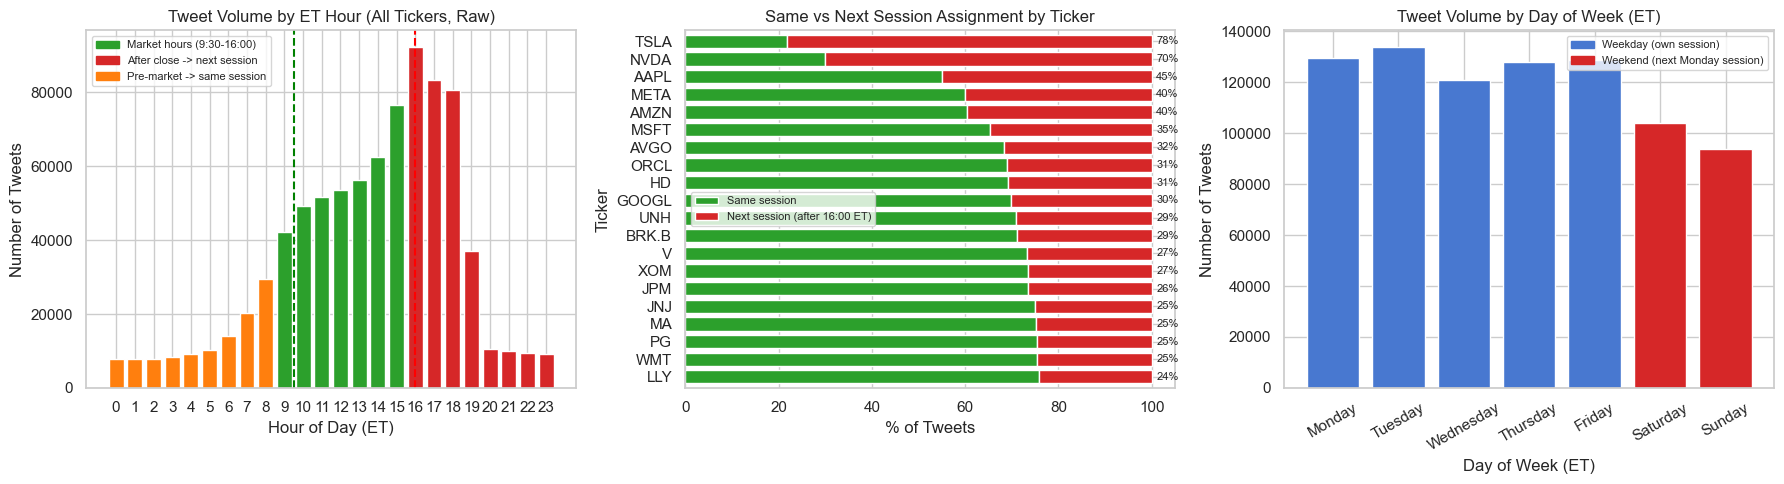


After-close tweet % by ticker:


,After-close tweets,Total tweets,Next-session %
ticker,,,
TSLA,74899,95749,78.2
NVDA,41114,58637,70.1
AAPL,23065,51253,45.0
META,18852,47181,40.0
AMZN,28942,72903,39.7
MSFT,21019,60751,34.6
AVGO,9375,29636,31.6
ORCL,6667,21428,31.1
HD,7176,23344,30.7


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load all raw tweet files — only post_date needed for this analysis
raw_dfs = []
for csv_file in csv_files:
    ticker = csv_file.replace("tweets_", "").replace(".csv", "")
    df_raw = pd.read_csv(os.path.join(INPUT_DIR, csv_file), usecols=["post_date"])
    df_raw["ticker"] = ticker
    raw_dfs.append(df_raw)

raw_all = pd.concat(raw_dfs, ignore_index=True)
raw_all["post_date_utc"] = pd.to_datetime(raw_all["post_date"], utc=True)
raw_all["post_date_et"] = raw_all["post_date_utc"].dt.tz_convert("America/New_York")

# Compute session assignment flags
sec = (
    raw_all["post_date_et"].dt.hour * 3600
    + raw_all["post_date_et"].dt.minute * 60
    + raw_all["post_date_et"].dt.second
)
raw_all["after_close"] = sec > 16 * 3600
raw_all["hour_et"] = raw_all["post_date_et"].dt.hour
raw_all["day_of_week"] = raw_all["post_date_et"].dt.day_name()

total = len(raw_all)
n_after = raw_all["after_close"].sum()
n_before = total - n_after

print(f"Total tweets (raw):                        {total:,}")
print(f"At/before 16:00 ET -> same session:        {n_before:,} ({n_before/total*100:.1f}%)")
print(f"After 16:00 ET     -> next session:        {n_after:,} ({n_after/total*100:.1f}%)")

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = raw_all["day_of_week"].value_counts().reindex(day_order).fillna(0).astype(int)
weekend_n = int(dow[["Saturday", "Sunday"]].sum())
print(f"Posted on weekends (ET, pushed to Monday): {weekend_n:,} ({weekend_n/total*100:.1f}%)")

# ── Figure 1: ET hour distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hour_counts = raw_all["hour_et"].value_counts().sort_index()

def hour_color(h):
    if 9 <= h < 16:
        return "#2ca02c"   # green: market hours, same session
    elif h >= 16:
        return "#d62728"   # red: after close, next session
    else:
        return "#ff7f0e"   # orange: pre-market, same session

colors = [hour_color(h) for h in hour_counts.index]
axes[0].bar(hour_counts.index, hour_counts.values, color=colors, edgecolor="white", width=0.8)
axes[0].axvline(9.5, color="green", linestyle="--", linewidth=1.5)
axes[0].axvline(16,  color="red",   linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Hour of Day (ET)")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Tweet Volume by ET Hour (All Tickers, Raw)")
axes[0].set_xticks(range(0, 24))
patch_mkt  = mpatches.Patch(color="#2ca02c", label="Market hours (9:30-16:00)")
patch_post = mpatches.Patch(color="#d62728", label="After close -> next session")
patch_pre  = mpatches.Patch(color="#ff7f0e", label="Pre-market -> same session")
axes[0].legend(handles=[patch_mkt, patch_post, patch_pre], fontsize=8)

# ── Figure 2: Same vs next session split by ticker ──────────────────────────
ticker_split = (
    raw_all.groupby("ticker")["after_close"]
    .agg(after_close_n="sum", total="count")
    .assign(
        same_pct=lambda d: (d["total"] - d["after_close_n"]) / d["total"] * 100,
        next_pct=lambda d: d["after_close_n"] / d["total"] * 100,
    )
    .sort_values("next_pct")
)
ticker_split[["same_pct", "next_pct"]].plot(
    kind="barh", stacked=True, ax=axes[1],
    color=["#2ca02c", "#d62728"], width=0.75,
)
axes[1].set_xlabel("% of Tweets")
axes[1].set_ylabel("Ticker")
axes[1].set_title("Same vs Next Session Assignment by Ticker")
axes[1].legend(["Same session", "Next session (after 16:00 ET)"], fontsize=8)
axes[1].set_xlim(0, 105)
for i, (_, row) in enumerate(ticker_split.iterrows()):
    axes[1].text(101, i, f"{row['next_pct']:.0f}%", va="center", fontsize=8)

# ── Figure 3: Day-of-week distribution in ET ────────────────────────────────
bar_colors = ["#4878d0"] * 5 + ["#d62728"] * 2
axes[2].bar(day_order, dow.values, color=bar_colors, edgecolor="white")
axes[2].set_xlabel("Day of Week (ET)")
axes[2].set_ylabel("Number of Tweets")
axes[2].set_title("Tweet Volume by Day of Week (ET)")
axes[2].tick_params(axis="x", rotation=30)
patch_wd = mpatches.Patch(color="#4878d0", label="Weekday (own session)")
patch_we = mpatches.Patch(color="#d62728", label="Weekend (next Monday session)")
axes[2].legend(handles=[patch_wd, patch_we], fontsize=8)

plt.tight_layout()
plt.show()

# ── Numeric summary per ticker ───────────────────────────────────────────────
print("\nAfter-close tweet % by ticker:")
display(
    ticker_split[["after_close_n", "total", "next_pct"]]
    .rename(columns={"after_close_n": "After-close tweets", "total": "Total tweets", "next_pct": "Next-session %"})
    .sort_values("Next-session %", ascending=False)
    .style.format({"Next-session %": "{:.1f}"})
)

In [10]:
# Build summary table (Wilksch & Abramova, 2023 style)
steps = list(global_statistic.keys())
counts = list(global_statistic.values())
deltas = [''] + [f'{counts[i] - counts[i-1]:+,}' for i in range(1, len(counts))]

summary_table = pd.DataFrame({
    'Step': steps,
    'n tweets after step': [f'{c:,}' for c in counts],
    'Δn': deltas,
})

print("Sample size during data cleaning stages:")
display(summary_table)

Sample size during data cleaning stages:


,Step,n tweets after step,Δn
0,Data collection,"838,982",
1,Remove messaging spam,"700,938","-138,044"
2,Drop duplicates,"641,726","-59,212"
3,Filter number of cashtags & hashtags,"515,974","-125,752"
4,Remove spam by ratios,"505,311","-10,663"
5,Remove cryptocurrency posts,"505,223",-88
6,Filter non-English,"424,543","-80,680"
7,Clean text for model,"422,921","-1,622"


## 9. Summary

**Pipeline:** `Raw_Data/Tweets/` → clean, filter, sentiment → `Processed_Data/tweets_sentiment_daily/`

**Output CSV Format (`TICKER_tweets_sentiment_daily.csv`):**
- `date`: NYSE trading session date
- `avg_sentiment`: Mean FinRoBERTa sentiment across all tweets for that day [-1, 1]
- `total_replies`: Sum of reply counts for all tweets that day
- `total_retweets`: Sum of retweet counts for all tweets that day
- `total_likes`: Sum of like counts for all tweets that day